## Donut 🍩, Document understanding transformer

![model image](https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/model_doc/donut_architecture.jpg)

[paper: OCR-free Document Understanding Transformer](https://huggingface.co/papers/2111.15664)

[clovaai/donut Github](https://github.com/clovaai/donut?tab=readme-ov-file)

[donut-base model on huggingface](https://huggingface.co/naver-clova-ix/donut-base/)


### TEXT FORMAT

**during training:**

- **INPUT:**
  - Image embedding
  - task_start_token + bos_token + json2token(ground_truth_json) + eos_token

**during inference:**

- **INPUT:**
  - Image embedding
  - task_start_token

- **OUTPUT:**
  - ground_truth_json

### NVIDIA RTX 5090 / 로컬(conda `donut_vml`) 환경 적용 — 문서 파싱(SROIE)

원본 Colab(`source_colab.ipynb`)을 로컬 RTX 5090 에 맞게 수정. 태스크 토큰 `<parsing>`, max_length 128.

**변경**: `fp16→bf16` · `/content`→로컬 · HF Hub 푸시 제거 · `report_to=none` · 추론 dtype bf16 +
`pixel_values` dtype 캐스팅(분류 노트북에서 겪은 bf16 mismatch 선제 수정) · 위젯 렌더 픽스.

> hftuner 는 transformers 5.12.1 에서 import/모델로드 검증됨(분류 노트북과 동일 라이브러리).
> SROIE 데이터셋은 첫 실행 시 HF 에서 다운로드됩니다.

In [1]:
# [로컬/VS Code] widget 렌더러 오류 방지 — datasets/HF 진행바를 텍스트 모드로 강제
import os
os.environ['TQDM_NOTEBOOK'] = 'false'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
# HF_TOKEN 미설정 경고는 공개 데이터(SROIE)엔 무해 — 필요시 토큰 설정(선택):
#   os.environ['HF_TOKEN'] = 'hf_...'
print('env 설정 완료')

env 설정 완료


In [2]:
# [로컬/RTX5090] donut_vml env 에 transformers 가 이미 설치돼 있습니다.
import transformers, torch
print("transformers", transformers.__version__, "| torch", torch.__version__, "| cuda", torch.cuda.is_available())

/home/jhkim/anaconda3/envs/donut_vml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformers 5.12.1 | torch 2.11.0+cu128 | cuda True


In [3]:
# [로컬] hftuner(clovaai-donut) 라이브러리를 이 노트북 폴더에 클론하고 import 경로 추가.
import os, sys
_here   = os.path.abspath(os.getcwd())
HFTUNER = os.path.join(_here, "hftuner")
if not os.path.isdir(HFTUNER):
    !git clone https://github.com/hftuner/clovaai-donut.git "{HFTUNER}"
if _here not in sys.path:
    sys.path.insert(0, _here)   # 부모 디렉터리 → `import hftuner` 가능
print("hftuner ready:", os.path.isdir(HFTUNER))

hftuner ready: True


In [4]:
import os
import json
from datasets import load_dataset

dataset = load_dataset('hf-tuner/SROIE-document-parsing')


In [5]:
dataset 

DatasetDict({
    train: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 875
    })
    test: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 98
    })
})

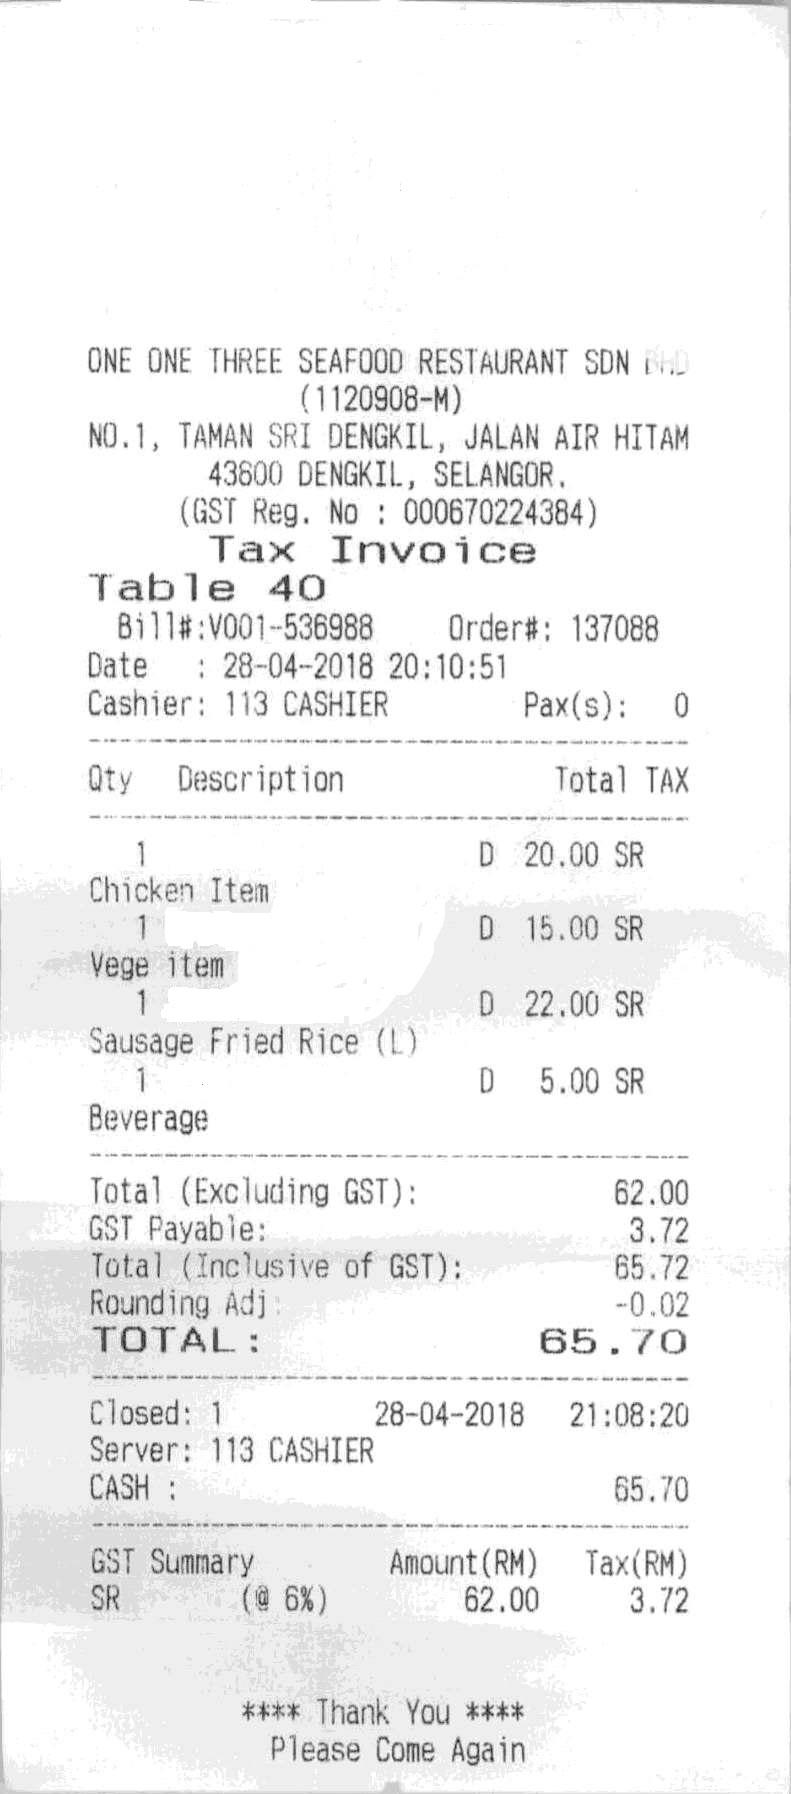

{"gt_parse": {"address": "no.1, taman sri dengkil, jalan air hitam 43800 dengkil, selangor.", "company": "one one three seafood restaurant sdn bhd", "date": "28-04-2018", "total": "65.70"}}


In [ ]:
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

ex = dataset['train'][0]
# Display the image
display(ex['image'])

print(ex["ground_truth"])

In [7]:
ignore_id = -100
task_start_token = "<parsing>"
new_special_tokens = []

new_special_tokens.extend([task_start_token])
new_special_tokens


['<parsing>']

In [8]:
from hftuner.donut import DataProcessor

data_processor = DataProcessor()
json2token = data_processor.json2token

example_vqa_gt = [
    {"question" : "what is the model name?", "answer" : "donut"},
     {"question" : "what is the model name?", "answer" : "document understanding transformer"}
    ] #gt_parses

example_document_classification_gt = {"class" : "scientific_report"} #gt_parse

example_doc_parsing_gt ={
    "menu": [
      {
        "nm": "[MD] SOFT STEAMED CHEESEC",
        "cnt": "2",
        "price": "20,000"
      },
      {
        "nm": "[MD] SOFT STEAMED CHOCOCA",
        "cnt": "2",
        "price": "20,000"
      }
    ],
    "total": {
      "total_price": "40,000",
      "cashprice": "100,000",
      "changeprice": "60,000"
    }
  } #gt_parse

from pprint import pprint

result = json2token(example_doc_parsing_gt)
print("json2token output:")
pprint(result)

json2token output:
('<s_total><s_total_price>40,000</s_total_price><s_changeprice>60,000</s_changeprice><s_cashprice>100,000</s_cashprice></s_total><s_menu><s_price>20,000</s_price><s_nm>[MD] '
 'SOFT STEAMED '
 'CHEESEC</s_nm><s_cnt>2</s_cnt><sep/><s_price>20,000</s_price><s_nm>[MD] SOFT '
 'STEAMED CHOCOCA</s_nm><s_cnt>2</s_cnt></s_menu>')


## special tokens from dataset

In [9]:
import json

def clean_docs_for_donut(sample):
    # ground_truth 파싱
    gt = json.loads(sample["ground_truth"])
    # 파싱 결과 선택
    parsed_text = gt['gt_parse'] if 'gt_parse' in gt else gt['gt_parses']
    # 토큰 변환 (key별 special token 추가)
    text = json2token(parsed_text, update_special_tokens_for_json_key=True)
    return {"text": text}

# 남길 컬럼만 제외 리스트화
columns_to_remove = [c for c in dataset['train'].column_names if c not in ['image', 'ground_truth', 'text']]

# special token 리셋
data_processor.clear_new_special_tokens()

# text 생성 및 필요 없는 컬럼 삭제
proc_dataset = dataset.map(clean_docs_for_donut, remove_columns=columns_to_remove)

# 추가된 special token 확인
new_key_tokens = data_processor.get_new_special_tokens()
print(f"New special tokens:  {new_special_tokens}")

# 변환된 text 예시 출력
print(f"Sample:\n{proc_dataset['train'][4]['text']}")
# bos_token and eos_token will be added by data collator function

New special tokens:  ['<parsing>']
Sample:
<s_total>174.90</s_total><s_date>03/03/2018</s_date><s_company>three stooges</s_company><s_address>109, ss21/1a, damansara utama</s_address>


## load model and processor

In [10]:
import torch
from transformers import DonutProcessor, VisionEncoderDecoderConfig
from hftuner.donut import DonutModel

ckpt = 'naver-clova-ix/donut-base'
processor = DonutProcessor.from_pretrained(ckpt)
model = DonutModel.from_pretrained(ckpt)

len(processor.tokenizer)
print(f"New tokenizer : {processor.tokenizer}")

Loading weights: 100%|██████████| 484/484 [00:00<00:00, 69648.44it/s]


New tokenizer : XLMRobertaTokenizer(name_or_path='naver-clova-ix/donut-base', vocab_size=57522, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	57521: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=True, special=True),
	57522: AddedToken("<sep/>", rstrip=False, lstrip=False, single_word=False, normalized=True, spec

### Configure processor and model for finetuning

In [11]:
# 새로운 special token과 key에서 추출한 토큰 합치고 중복제거
new_special_tokens = list(set(new_special_tokens + new_key_tokens))
print(f"New special tokens:  {new_special_tokens}")

# 토크나이저에 새로운 special token 추가
print(f"Adding {len(new_special_tokens)} special tokens")
processor.tokenizer.add_special_tokens({"additional_special_tokens": new_special_tokens})

# (중요) 전체 토큰 수가 64 배수가 아니면, <reserved_x> 더미 토큰 추가해서 64배수 맞춤
multiplier = 64
if len(processor.tokenizer) % multiplier != 0:
    extra_token_count = multiplier - (len(processor.tokenizer) % multiplier)
    print(f"Adding {extra_token_count} fake tokens")
    fake_tokens = [f"<reserved_{i+1}>" for i in range(extra_token_count)]
    processor.tokenizer.add_tokens(fake_tokens)

print(f"New tokenizer length: {len(processor.tokenizer)}")


New special tokens:  ['<parsing>']
Adding 1 special tokens
Adding 10 fake tokens
New tokenizer length: 57536


In [12]:
# 각 예제의 토큰 수 계산 (학습 중 출력 길이 제한에 사용)
def add_token_count(example):
    # text를 tokenize하여 토큰 개수를 세서 tokens_count에 저장
    example['tokens_count'] = processor.tokenizer(
        example['text'],
        add_special_tokens=True,
        return_tensors="pt"
    ).input_ids[0].shape[0]
    return example

# 모든 데이터셋에 위 함수 적용
proc_dataset = proc_dataset.map(add_token_count)
print(proc_dataset['train'][0])

# 전체 학습 데이터에서 가장 긴 토큰 길이 확인 (max_length 설정 시 참고)
max_length = max(proc_dataset['train']['tokens_count'])
print('maximum length of example:', max_length)

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=791x1794 at 0x79434DF3B610>, 'ground_truth': '{"gt_parse": {"address": "no.1, taman sri dengkil, jalan air hitam 43800 dengkil, selangor.", "company": "one one three seafood restaurant sdn bhd", "date": "28-04-2018", "total": "65.70"}}', 'text': '<s_total>65.70</s_total><s_date>28-04-2018</s_date><s_company>one one three seafood restaurant sdn bhd</s_company><s_address>no.1, taman sri dengkil, jalan air hitam 43800 dengkil, selangor.</s_address>', 'tokens_count': 93}
maximum length of example: 129


In [13]:
max_length = 128
processor_image_size = [1280, 1600] # (width, height) — 추가 상향(960x1280 대비 company/address 개선)

## UPDATE: processor
processor.image_processor.size['width'] = processor_image_size[0]
processor.image_processor.size['height'] = processor_image_size[1]
processor.image_processor.do_align_long_axis = False # don't rotate image if height is greater than width

## UPDATE: model

# generation config
model.config.decoder.max_length = max_length
model.config.pad_token_id = processor.tokenizer.pad_token_id

# ⚠️ IMPORTANT: set decoder_start_token
task_token_id = processor.tokenizer.encode(task_start_token, add_special_tokens=False)[0]
print(task_token_id, task_start_token)
model.config.decoder_start_token_id = task_token_id

# Resize embedding layer to match vocabulary size
new_emb = model.decoder.resize_token_embeddings(len(processor.tokenizer))

# Adjust our image size and output sequence lengths
model.config.encoder.image_size = processor_image_size[::-1] # (height, width)
model.config.use_cache = False   # gradient checkpointing 과 호환(아래 학습인자)

print(f"New token embedding size: {new_emb}")

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


57525 <parsing>
New token embedding size: MBartScaledWordEmbedding(57536, 1024, padding_idx=1)


More about : [decoder_start_token_id](https://github.com/huggingface/transformers/blob/4df2529d79d75f44e70396df5888a32ffa02d61e/src/transformers/models/vision_encoder_decoder/modeling_vision_encoder_decoder.py#L331)

## Data Collator

In [14]:
def prepare_data(examples):
    images = [e['image'].convert("RGB") for e in examples]
    texts = [e['text'] for e in examples]
    
    # create tensor from image
    pixel_values = processor(
        images,
        return_tensors="pt"
        ).pixel_values
    
    # tokenize text
    input_ids = processor.tokenizer(
        texts,
        add_special_tokens=True, # add <s> and </s>
        max_length=max_length,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    ).input_ids
    labels = input_ids.clone()
    # print('labels', labels)
    
    # ignore pad tokens when calculating `loss`
    labels[labels == processor.tokenizer.pad_token_id] = ignore_id
    return {"pixel_values": pixel_values, "labels": labels}

# TEST
batch= prepare_data([
    proc_dataset['train'][5],
])
batch.keys(), batch['pixel_values'].shape, batch['labels'].shape

(dict_keys(['pixel_values', 'labels']),
 torch.Size([1, 3, 1600, 1280]),
 torch.Size([1, 128]))

## ⚙️ Train

In [15]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, EarlyStoppingCallback

save_model_name = "donut-base-finetuned-sroie"

# [로컬/RTX5090] Hub 푸시 제거 + Early Stopping(전체 학습용) 설정.
training_args = Seq2SeqTrainingArguments(
    output_dir=save_model_name,
    num_train_epochs=10,              # 상한값 — early stopping 이 보통 더 일찍 멈춤
    # max_steps=100,                  # ← (데모) 주석 풀면 100스텝 빠른 확인. 단 너무 짧아 early stop 무력화
    learning_rate=2e-5,
    warmup_ratio=0.1,                 # 총 스텝의 10% 워밍업 — 초반 안정화(새 토큰 임베딩 대비)
    lr_scheduler_type="cosine",       # 기본 linear → cosine 감소
    per_device_train_batch_size=1,    # RTX 5090(32GB): GPU가 비면 2~4 까지
    per_device_eval_batch_size=1,
    weight_decay=0.01,
    bf16=True,        # [RTX 5090/Donut] fp16 은 Donut 수치 불안정 → bf16
    gradient_checkpointing=True,      # 고해상도(1280x1600) 활성값 메모리 절감(연산↑·메모리↓)
    fp16=False,
    # ── 평가/저장/로깅을 같은 간격(steps)으로 일치 (early stopping 필수 조건) ──
    eval_strategy="steps",
    save_strategy="steps",            # ★ eval 과 동일 전략 (안 맞추면 load_best 에러)
    eval_steps=100,
    save_steps=100,
    logging_steps=100,                # train/validation loss 같은 행에 출력
    save_total_limit=2,
    predict_with_generate=False,      # eval=빠른 loss 계산만 (생성 데모는 추론 셀에서 별도)
    # ── Early Stopping: eval_loss 최저(best) 체크포인트를 학습 후 자동 복원 ──
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,          # loss 는 낮을수록 좋음
    report_to="none",
    push_to_hub=False,
    remove_unused_columns=False,
)

# Create Trainer — eval_loss 가 patience(=3) 회 연속 개선 없으면 학습 중단
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    data_collator=prepare_data,
    train_dataset=proc_dataset["train"],
    eval_dataset=proc_dataset["test"],
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [16]:
# Start training
trainer.train()

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss
100,5.357598,3.114803
200,2.148084,0.835299
300,0.781176,0.343259
400,0.391774,0.222792
500,0.293598,0.175817
600,0.252273,0.152880
700,0.179652,0.136833
800,0.181261,0.126973
900,0.157851,0.115378
1000,0.139054,0.127438


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.29it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['decoder.lm_head.weight'].


TrainOutput(global_step=1900, training_loss=0.5630407938204314, metrics={'train_runtime': 424.2313, 'train_samples_per_second': 20.626, 'train_steps_per_second': 20.626, 'total_flos': 9.9018868948992e+18, 'train_loss': 0.5630407938204314, 'epoch': 2.1714285714285713})

In [17]:
# [로컬] 로컬 저장만 — HF Hub 푸시/모델카드 제거
trainer.save_model(save_model_name)
processor.save_pretrained(save_model_name)
print("saved ->", os.path.abspath(save_model_name))

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.26it/s]

saved -> /home/jhkim/donut_vml/donut_finetune_parsing/donut-base-finetuned-sroie


## 🚀 Inference

In [18]:
import re
import torch
from transformers import DonutProcessor, VisionEncoderDecoderConfig
from hftuner.donut import DonutModel

ckpt = save_model_name   # [로컬] 위에서 학습·저장한 모델
# ckpt = "hf-tuner/donut-base-finetuned-sroie"  # 또는 허브 모델

config    = VisionEncoderDecoderConfig.from_pretrained(ckpt)
processor = DonutProcessor.from_pretrained(ckpt)
device    = "cuda" if torch.cuda.is_available() else "cpu"
# [RTX 5090/Donut] fp16 대신 bf16
config.dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

model = DonutModel.from_pretrained(ckpt, config=config)
model.to(device)

Loading weights: 100%|██████████| 483/483 [00:00<00:00, 8465.27it/s]


DonutModel(
  (encoder): DonutSwinModel(
    (embeddings): DonutSwinEmbeddings(
      (patch_embeddings): DonutSwinPatchEmbeddings(
        (projection): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): DonutSwinEncoder(
      (layers): ModuleList(
        (0): DonutSwinStage(
          (blocks): ModuleList(
            (0): DonutSwinLayer(
              (layernorm_before): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (attention): DonutSwinAttention(
                (self): DonutSwinSelfAttention(
                  (query): Linear(in_features=128, out_features=128, bias=True)
                  (key): Linear(in_features=128, out_features=128, bias=True)
                  (value): Linear(in_features=128, out_features=128, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )
              

In [19]:
from datasets import load_dataset

dataset = load_dataset('hf-tuner/SROIE-document-parsing')

[test][3]  GT vs Prediction  (영수증 순서)
------------------------------------------------------------
 O company
     GT  : hugo trading sdn bhd
     PRED: hugo trading sdn bhd
 X address
     GT  : 889, kompleks pasar borong .d are selangor, 43300 seri kembangan, sel
     PRED: lot 889, kompleks pasar borong selangor. 43300 seri kembangan, sel
 O date
     GT  : 13/01/2018
     PRED: 13/01/2018
 X total
     GT  : 40.80
     PRED: 22.00
------------------------------------------------------------
필드 일치: 2/4


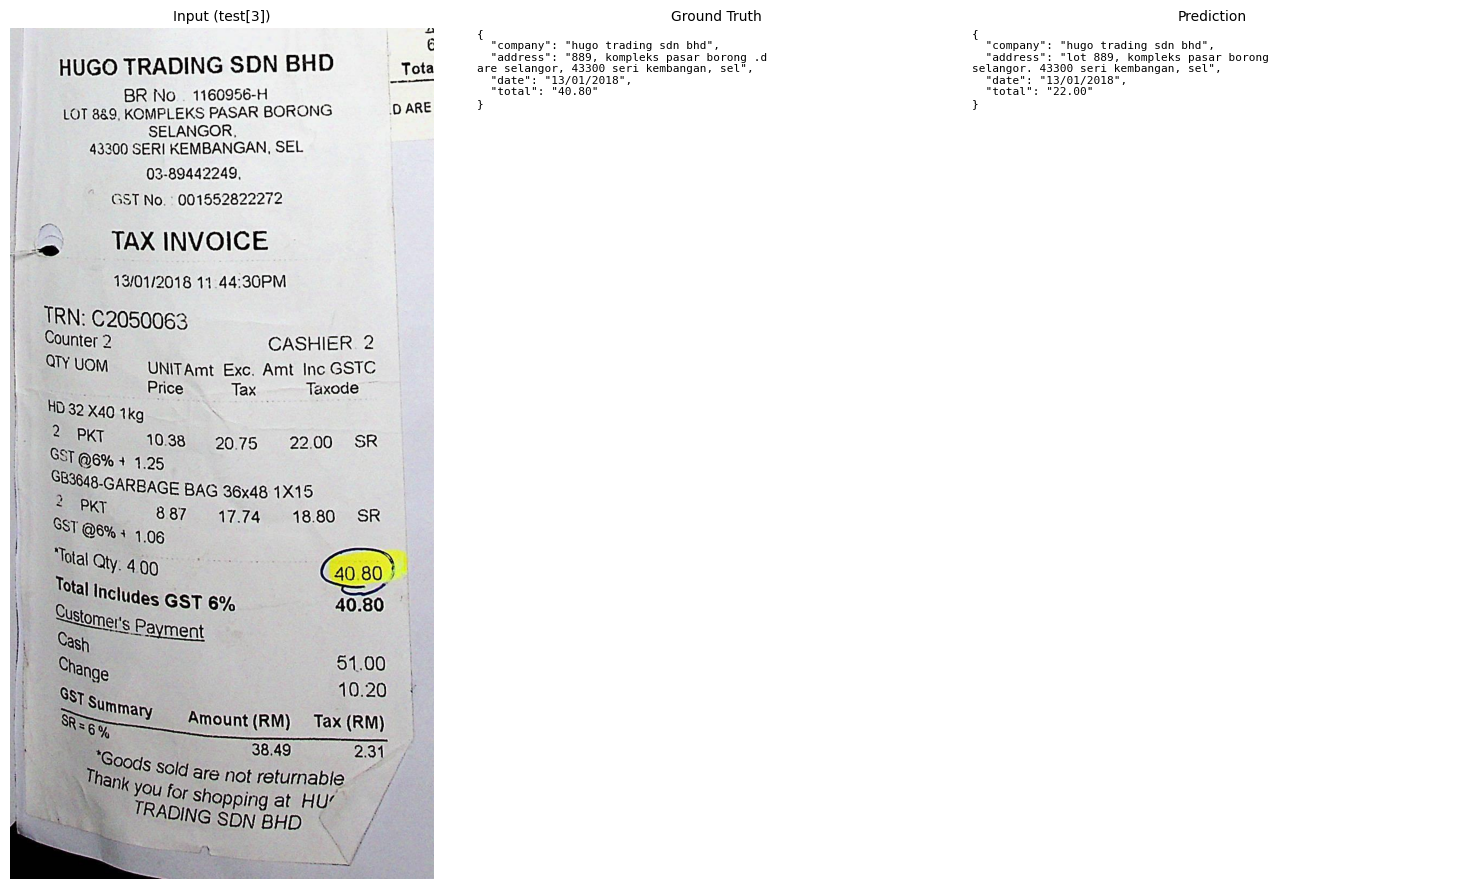

In [22]:
# inference (generation) — 입력 이미지 | 정답(GT) | 예측 3단 비교 (영수증 표기 순서)
import json, textwrap
import matplotlib.pyplot as plt

SAMPLE_SPLIT, SAMPLE_IDX = "test", 3      # 비교할 샘플 (바꾸려면 여기만 수정)
sample = dataset[SAMPLE_SPLIT][SAMPLE_IDX]

# ── 영수증에 보이는 순서(위→아래)로 키를 정렬. 목록에 없는 키는 뒤에 그대로 ──
RECEIPT_ORDER = ["company", "address", "date", "total"]
def order_keys(d):
    if not isinstance(d, dict):
        return d
    keys = [k for k in RECEIPT_ORDER if k in d] + [k for k in d if k not in RECEIPT_ORDER]
    return {k: d[k] for k in keys}

# ── 추론 ──
pixel_values = processor(sample['image'], return_tensors="pt").pixel_values.to(device, model.dtype)
decoder_input_ids = processor.tokenizer("<parsing>", add_special_tokens=False,
                                         return_tensors="pt").input_ids.to(device)
generated_ids = model.generate(pixel_values, decoder_input_ids=decoder_input_ids,
                               max_length=128, bad_words_ids=[[processor.tokenizer.unk_token_id]])
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
pred = processor.token2json(generated_text)

# ── 정답(GT) 로드 ──
gt_raw = json.loads(sample['ground_truth'])
gt = gt_raw.get('gt_parse', gt_raw.get('gt_parses'))

# ── 영수증 순서로 정렬(GT·예측 동일 기준) ──
gt_disp, pred_disp = order_keys(gt), order_keys(pred)

# ── 콘솔: 필드별 GT vs 예측 (영수증 순서, O/X) ──
print(f"[{SAMPLE_SPLIT}][{SAMPLE_IDX}]  GT vs Prediction  (영수증 순서)")
print("-" * 60)
if isinstance(gt, dict) and isinstance(pred, dict):
    order = [k for k in RECEIPT_ORDER if k in gt or k in pred]
    order += [k for k in list(gt) + list(pred) if k not in order]
    hit = 0
    for k in order:
        g, p = gt.get(k), pred.get(k)
        ok = (g == p); hit += ok
        print(f" {'O' if ok else 'X'} {k}")
        print(f"     GT  : {g}")
        print(f"     PRED: {p}")
    print("-" * 60)
    print(f"필드 일치: {hit}/{len(order)}")
else:
    print("GT :", gt); print("PRED:", pred)

# ── 시각화: Input | Ground Truth | Prediction (둘 다 영수증 순서) ──
def _fmt(o):
    t = json.dumps(o, indent=2, ensure_ascii=False)
    return "\n".join(textwrap.fill(l, 46) for l in t.splitlines())

fig, axes = plt.subplots(1, 3, figsize=(15, 9), gridspec_kw={"width_ratios": [1, 1, 1]})
axes[0].imshow(sample['image'].convert("RGB")); axes[0].axis("off")
axes[0].set_title(f"Input ({SAMPLE_SPLIT}[{SAMPLE_IDX}])", fontsize=10)
axes[1].axis("off"); axes[1].set_title("Ground Truth", fontsize=10)
axes[1].text(0, 1, _fmt(gt_disp), transform=axes[1].transAxes, va="top", ha="left",
             fontsize=8, family="monospace")
axes[2].axis("off"); axes[2].set_title("Prediction", fontsize=10)
axes[2].text(0, 1, _fmt(pred_disp), transform=axes[2].transAxes, va="top", ha="left",
             fontsize=8, family="monospace")
plt.tight_layout(); plt.show()

## 📊 최종 성능 평가 (SROIE test 98장)

**평가 방법**: test셋 전 샘플을 추론 → 필드별 **완전일치(exact match, 정규화 후)** → Precision/Recall/F1.
`MACRO F1` = 4필드 평균, `완전일치` = 4필드 모두 정확한 레코드 비율. (예: `scratchpad/eval_parsing.py`)

### 해상도별 비교 (image_size 영향)

| 해상도 (W×H) | company | address | date | total | **MACRO F1** | **완전일치** | best eval_loss |
|---|--:|--:|--:|--:|--:|--:|--:|
| 720×960 | 0.649 | 0.443 | 0.722 | 0.704 | 0.630 | 23.5% | 0.217 |
| 960×1280 | 0.660 | 0.574 | 0.891 | 0.755 | 0.720 | 34.7% | 0.224 |
| **1280×1600** (현재) | **0.742** | **0.649** | **0.892** | **0.755** | **0.760** | **36.7%** | **0.186** |

### 핵심 발견

- **해상도가 SROIE 성능의 주요 레버**: 720×960 → 1280×1600 으로 MACRO F1 **0.63 → 0.76**, 레코드 완전일치 **23.5% → 36.7%**.
- **작은 글자 필드가 해상도 이득을 크게 받음**: `address`(0.44→0.65), `date`(0.72→0.89). 큰 글자인 `company`는 1280×1600 에서 비로소 상승(0.66→0.74).
- **수확체감**: 720→960 (+0.09) 보다 960→1280 (+0.04) 이득이 절반 이하. `date`·`total` 은 960×1280 에서 이미 포화.
- **eval_loss ≠ 필드 정확도**: 720×960(0.217) vs 960×1280(0.224) 은 eval_loss 가 비슷/역전인데 필드 F1 은 크게 차이 → **손실만 보지 말고 필드 단위로 평가**할 것.

### 다음 레버

해상도는 한계 근접(포화 시작). 추가 향상은 **① 학습 데이터 추가 ② 더 긴 학습**(현재 early stopping 으로 ~2.5 epoch 에서 종료)에서 기대.

> 학습 조건: donut-base, bf16, batch 1, warmup 0.1 + cosine, early stopping(patience 3), 1280×1600 은 gradient checkpointing 사용.
